# Додаткове завдання до модуля 4: візуалізація даних.
В цьому ДЗ ми будемо багато працювати не тільки з візуалізаціями, а і з функціоналом pandas, адже візуалізація даних - це частина аналізу даних та працює спільно з агрегацією та фільтрацією наших даних. До того ж перед тим, як аналізувати дані, їх треба почистити. Чим ми і займемось.  

0.Імпортуйте бібліотеки matplotlib.pyplot, seaborn та pandas.

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Набір даних Taxis

Використовуючи метод з бібліотеки `seaborn` `load_dataset` ми завантажимо перший набір даних для аналізу. Завантажимо дані так, бо це зручно + аби ви знали, що є і така можливість знайти собі набір даних для експериментів.  
Набір даних містить поїздки таксі у Нью Йорку у 2019 році. Детальний опис на [сайті](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page).  

Які колонки мість набір даних:  
- `pickup` - час початку поїздки  
- `dropoff` - час закінчення поїздки  
- `passengers` - кількість пасажирів у поїздці  
- `distance` - відстань поіздки  
- `fare` - базова плата за поїздку  
- `tip` - розмір чайових  
- `tolls` - плата за платні дороги (за це також платить пасажир)  
- `total` - сумарна плата за поїздку  
- `color` - колір авто, яке здійснювало поїздку  
- `payment` - метод оплати  
- `pickup_zone` - зона, у якій почалась поїздка  
- `dropoff_zone` - зона, у якій закінчилась поїздка  
- `pickup_borough` - район, у якому почалась поїздка  
- `dropoff_borough` - район, у якому закінчилась поїздка  

Назви ознак здбільшого говорять самі за себе. Слово borough перекладається з англійської як "район".

Ми будемо працювати сами з тим шматочком даних, які наявні в seaborn.  
Переглянути всі набори даних з seaborn можна [тут](https://github.com/mwaskom/seaborn-data).

Спершу - завантажуємо дані - просто виконайте клітинку нижче.

In [31]:
df_taxi = sns.load_dataset('taxis')

1.Виведіть
- перші 3 записи з набору даних
- типи даних в наборі даних df_taxi
- розміри набору даних

In [32]:
first_three_records = df_taxi.head(3)
first_three_records

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan


In [33]:
data_types = df_taxi.dtypes

data_types

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object

In [34]:
data_shape = df_taxi.shape

data_shape

(6433, 14)

Очікуваний результат (можна вивести в окремих клітинках):

![](https://drive.google.com/uc?export=view&id=1rsgJvFEdXwGDTVl3CyyRL2ao8rzR_8P2)

2.Перевіримо, чи є в цьому наборі даних пропущені значення. Для цього можемо вивести кількість пропущених значень в кожній колонці наступним чином (це надзвичайно корисна команда, запамʼятайте її):

In [35]:
df_taxi.isna().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Цікаво, чому дані відсутні? Відповідь на це питання нам дасть розуміння, чи можна такі дані видалити, чи можливо їх треба якось заповнити. Виведіть на екран ті рядки, де колонка, яка має найбільше пропущених значень (або одна з тих, що має максимальну кількість пропущених), має пропущені значення.
Подивіться на результат і напишіть свої думки щодо питань:
- чому на ваш погляд в цих рядках є відстуні дані в кількох колонках? Чому ви так думаєте?
- чому на ваш погляд є рядки з distance==0, а total!=0? Як ви до цього прйишли?
Відповідь просто текстом. Можна використовувати будь-які допоміжні операції над датасетом чи джерела, які допоможуть вам відповісти на ці питання. Якщо щось використовуєте, то це треба зазначити у відповіді.  

Ваша відповідь тут - це 70% виконання цього завдання.

In [36]:
missing_values = df_taxi.isna().sum()

max_missing_col = missing_values.idxmax()

rows_with_missing = df_taxi[df_taxi[max_missing_col].isna()]

missing_values, rows_with_missing

(pickup              0
 dropoff             0
 passengers          0
 distance            0
 fare                0
 tip                 0
 tolls               0
 total               0
 color               0
 payment            44
 pickup_zone        26
 dropoff_zone       45
 pickup_borough     26
 dropoff_borough    45
 dtype: int64,
                   pickup             dropoff  passengers  distance   fare  \
 42   2019-03-30 23:59:14 2019-03-30 23:59:17           1      0.00   80.0   
 622  2019-03-12 19:52:36 2019-03-12 19:52:55           3      0.00  120.0   
 711  2019-03-21 17:39:50 2019-03-21 18:12:54           2      1.74   17.0   
 739  2019-03-14 00:09:17 2019-03-14 00:09:21           1      0.03    2.5   
 970  2019-03-29 00:02:00 2019-03-29 00:02:05           2      0.00   45.0   
 1108 2019-03-10 09:33:13 2019-03-10 09:52:04           1     13.40   52.0   
 1112 2019-03-12 19:09:23 2019-03-12 19:20:46           1      0.90    8.5   
 1230 2019-03-29 07:52:46 2019-03-29 08

1. Пропущені значення в колонках payment, pickup_zone, dropoff_zone, pickup_borough і dropoff_borough можуть виникати через різні причини. Ось кілька можливих пояснень:
 - payment: Можливо, деякі пасажири не надали інформацію про метод оплати, або ця інформація не була правильно зібрана під час запису даних.
  - pickup_zone, dropoff_zone, pickup_borough, dropoff_borough: Відсутність даних в цих колонках може бути спричинена тим, що GPS-дані були неповними або не точними, і система не змогла визначити ці зони чи райони.

2. Рядки з distance==0, але з total!=0 можуть виникати через наступні причини:

 - Мінімальний тариф: Деякі таксі мають мінімальну плату за поїздку, навіть якщо відстань дуже коротка або дорівнює нулю. Це може включати посадковий тариф або фіксовану плату за виклик таксі.
 - Збої в системі GPS: Можливо, GPS не зміг правильно визначити початкову або кінцеву точку поїздки, тому відстань зареєстрована як 0, але пасажир все одно оплатив мінімальний тариф або плату за виклик.
 - Оплата за інші послуги: Навіть якщо відстань нульова, можуть бути інші збори, такі як чайові або плата за використання платних доріг.

Таким чином, наявність таких рядків можна пояснити особливостями тарифікації та можливими технічними збої у системі збирання даних.

3.Заповнимо пусті значення. Оскільки всі колонки набору даних мають пропущені значення в рядках з типом даних рядок, заповнимо пропущені значення рядком `NA`.
Створіть набір даних `df_taxi_clean`, який містить дані `df_taxi` із заповненими пропущеними значеннями у всіх колонках (де ті значення відсутні) значенням `NA`.

**УВАГА!** Надалі в роботі треба використовувати `df_taxi_clean`, ми ж його і створили для того, аби далі ним користуватись :)

In [37]:
df_taxi_clean = df_taxi.fillna('NA')

print(df_taxi_clean.head(10))

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   
5 2019-03-11 10:37:23 2019-03-11 10:47:31           1      0.49   7.5  2.16   
6 2019-03-26 21:07:31 2019-03-26 21:17:29           1      3.65  13.0  2.00   
7 2019-03-22 12:47:13 2019-03-22 12:58:17           0      1.40   8.5  0.00   
8 2019-03-23 11:48:50 2019-03-23 12:06:14           1      3.63  15.0  1.00   
9 2019-03-08 16:18:37 2019-03-08 16:26:57           1      1.52   8.0  1.00   

   tolls  total   color      payment                pickup_zone  \
0    0.0  12.95  yellow  credit card            Lenox Hill West

Після виконання завдання запустіть наступну клітинку:

In [38]:
df_taxi_clean.isna().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=1G5_k_jmtNFFRdn7Kcw_fEoJyrkTeOGP4)

4.Хочеться подивитись на дані у динаміці. Перетворіть колонку `pickup` набору даних `df_taxi_clean` (нам нема чого працювати з "брудними" даними, якщо ми їх вже почистили, але хай будуть в окремій змінній про всяк випадок) у формат `datetime64[ns]`.
Якщо у Вас при завантаженні набору даних колонка `pickup`- вже в форматі `datetime64[ns]` - можете пропустити це завдання, або спробувати все ж таки написат функцію для трансформації.

Результат перетворення збережіть в тій самій колонці `pickup`.

In [39]:
df_taxi_clean['pickup'] = pd.to_datetime(df_taxi_clean['pickup'])

print(df_taxi_clean.dtypes)

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object


Після виконання завдання запустіть наступну клітинку:

In [40]:
df_taxi_clean.pickup.head(3)

0   2019-03-23 20:21:09
1   2019-03-04 16:11:55
2   2019-03-27 17:53:01
Name: pickup, dtype: datetime64[ns]

Очікуваний результат виконання коду в попердній клітинці:

![](https://drive.google.com/uc?export=view&id=106hQKdEhLV3OIeFsP8yvXLo0cKk6Jmqo)

5.У нас колонка pickup зараз мість дані у форматі дата-час. Пропоную прибрати час і зробити аналітику по дням. Для цього виконайте клатинку нижче:

In [41]:
df_taxi_clean['pickup_day'] = df_taxi_clean.pickup.dt.floor('d')

А тепер згрупуйте дані по pickup_day та виведіть графік сумарних платежів по дням. УВАГА! Якщо хочете отримати підписи по осі ОХ як на прикладі, то графік необхідно будувати через `df.plot(...)`. Якщо у Вас будуть інші підписи осі ОХ - це ОК.

Після виведення графіку скажіть, чи бачите щось дивне на ньому? Важливо написати відповідь в цьому завданні словами.

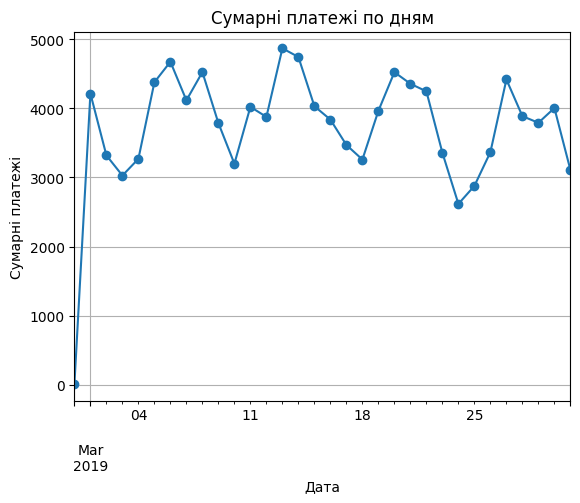

In [42]:
daily_totals = df_taxi_clean.groupby('pickup_day')['total'].sum()

daily_totals.plot(kind='line', marker='o', title='Сумарні платежі по дням')
plt.xlabel('Дата')
plt.ylabel('Сумарні платежі')
plt.grid(True)
plt.show()


Схоже, що під кінець тижня відбувалося менше платежів, а на початку - більше

Приклад очікуваного графіку:

![](https://drive.google.com/uc?export=view&id=1t8yb_NNO2tfwDFDrBNl0BLJoYB0BsUK_)

6.Виведіть кількість рядків для кожного pickup_day.

In [43]:
pickup_day_counts = df_taxi_clean.groupby('pickup_day').size()

pickup_day_counts

pickup_day
2019-02-28      1
2019-03-01    241
2019-03-02    198
2019-03-03    169
2019-03-04    171
2019-03-05    228
2019-03-06    257
2019-03-07    218
2019-03-08    235
2019-03-09    204
2019-03-10    185
2019-03-11    209
2019-03-12    218
2019-03-13    244
2019-03-14    260
2019-03-15    201
2019-03-16    220
2019-03-17    178
2019-03-18    173
2019-03-19    201
2019-03-20    233
2019-03-21    221
2019-03-22    229
2019-03-23    209
2019-03-24    149
2019-03-25    155
2019-03-26    178
2019-03-27    232
2019-03-28    205
2019-03-29    209
2019-03-30    215
2019-03-31    187
dtype: int64

Маєте побачити, що для дати 2019-02-28 є тільки один рядок. Це запис, який, схоже, потрапив сюди випадково, видаліть з набору даних df_taxi_clean рядок, що містить pickup_day рівний 2019-02-28. Та знову виведіть графік сумарних платежів по pickup_day.

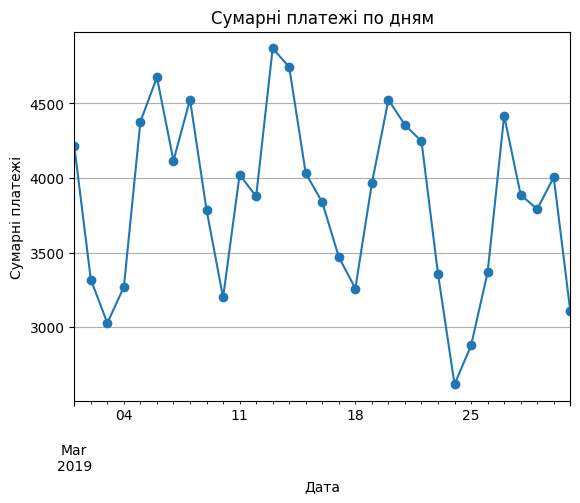

In [44]:
df_taxi_clean = df_taxi_clean[df_taxi_clean['pickup_day'] != '2019-02-28']

daily_totals = df_taxi_clean.groupby('pickup_day')['total'].sum()

daily_totals.plot(kind='line', marker='o', title='Сумарні платежі по дням')
plt.xlabel('Дата')
plt.ylabel('Сумарні платежі')
plt.grid(True)
plt.show()


Очікуваний графік:

![](https://drive.google.com/uc?export=view&id=1RfSjsgr5991dlz5bVbfXl8tCnUZhFJ8B)

7.Давайте подивимось на динаміку сумарних платежів по районам. Для цього сформуйте на основі `df_taxi_clean` зводну таблицю, де рядками є `pickup_day`, колонками `pickup_borough`, а значенням - сума платежів. Запишіть зводну таблицю в змінну `borough_pivot`. Наостанок, вилучіть колонку зі значенням `pickup_borough` рівним `NA` - уявімо, що ці дані нас не цікавлять.

In [45]:
borough_pivot = df_taxi_clean.pivot_table(
    values='total',
    index='pickup_day',
    columns='pickup_borough',
    aggfunc='sum',
    fill_value=0
)

borough_pivot = borough_pivot.drop(columns='NA', errors='ignore')

borough_pivot.head()


pickup_borough,Bronx,Brooklyn,Manhattan,Queens
pickup_day,,,,
2019-03-01,123.42,353.05,3169.47,553.29
2019-03-02,0.00,146.56,2716.33,456.13
2019-03-03,80.75,407.06,2100.23,428.73
2019-03-04,92.00,188.73,2026.17,962.18
2019-03-05,98.16,558.40,2981.26,739.56


Далі запустіть наступну клітинку та дайте відповідь на питання, в якому районі найчастіше найбільша сума денних платежів за поїздки на таксі?   
До речі, також рекомендую спробувати запустити команду `borough_pivot.plot()` та зрозуміти, навіщо нам тут частина `fillna(0)`.

>Використання fillna(0) дозволяє замінити NaN на 0 та забезпечити правильне відображення даних, оскільки при проведенні обчислень наявність NaN може призвести до помилок або неправильних результатів.



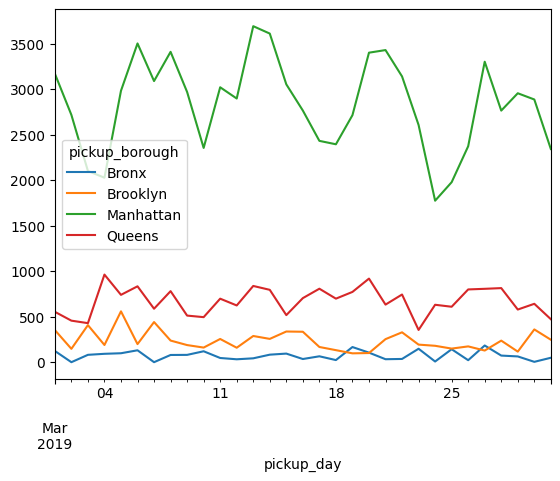

In [46]:
borough_pivot.fillna(0).plot();

Отже, найбільша сума денних платежів за поїздки на таксі в районі Manhattan

Очікуваний графік :

![](https://drive.google.com/uc?export=view&id=1zhLnMdPCg54j2yzU1hRWv6wseSNPT1Oy)

8.Виведіть будь-яким способом гістограми суми денних платежів за поїздки по кожному з районів. Має бути 4 гістограми, на 4ох різних фігурах, або на одній.   

`Підказка:` Найпростіше це буде зробити, використавши `borough_pivot` та побудову графіку через `<назва датафрейму>.<назва графіку>()` - тобто методом датафрейму з пандаса. Але графік можна побудувати також використовуючи цикл. Для тих, хто хоче потренуватись, рекомендую зробити обома способами.

Пограйтесь з кількістю бінів. Яка кількість бінів на ваш погляд тут є вдалою? Чому?

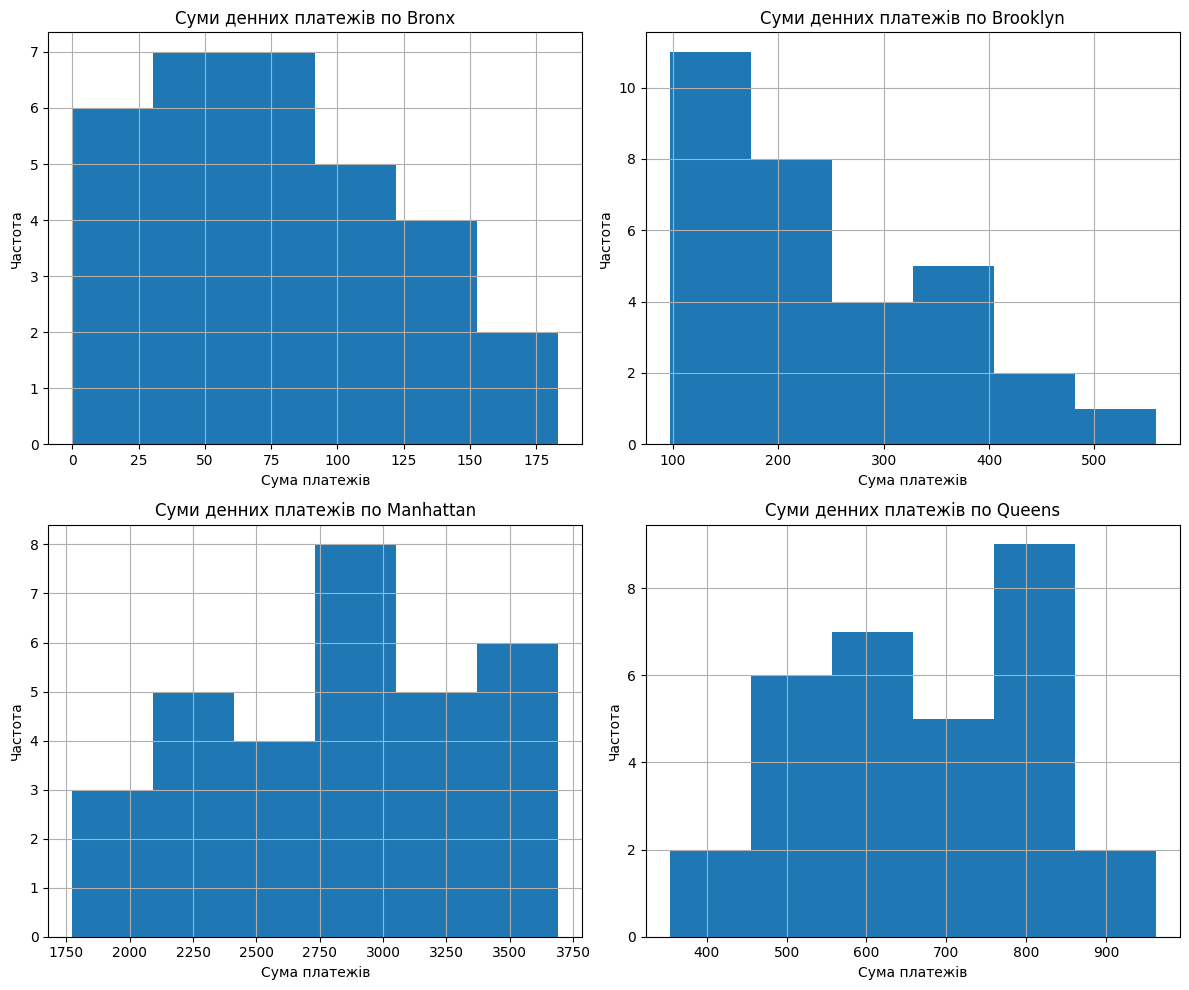

In [47]:
import matplotlib.pyplot as plt

bins = 6 #оптимальне значення

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

boroughs = ['Bronx', 'Brooklyn', 'Manhattan', 'Queens']
titles = ['Суми денних платежів по Bronx', 'Суми денних платежів по Brooklyn', 'Суми денних платежів по Manhattan', 'Суми денних платежів по Queens']

for i, ax in enumerate(axs.flat):
    borough_pivot[boroughs[i]].plot(kind='hist', bins=bins, ax=ax)
    ax.set_title(titles[i])
    ax.set_xlabel('Сума платежів')
    ax.set_ylabel('Частота')
    ax.grid(True)

plt.tight_layout()
plt.show()


Приклад одного з правильних виконань завдання:

![](https://drive.google.com/uc?export=view&id=1AfkIgwUAtaDiYoiK6NBOqCHBdUngRz4z)

9.Бачимо, що на окремих гістограмах у нас різні діапазони чеків. Припустимо, нам хочеться порівняти розподіли денних сум платежів по райнам. Давайте для цього виведемо 4 гістограми на одній фігурі. Вони звісно ж мають бути різного кольору і напівпрозорими для комфортного перегляду. Створіть гістограму максимально близьку до тої, що надана в очікуваному результаті.
`Підказка:` ця візуалізація створена з допомогою pandas plotting.

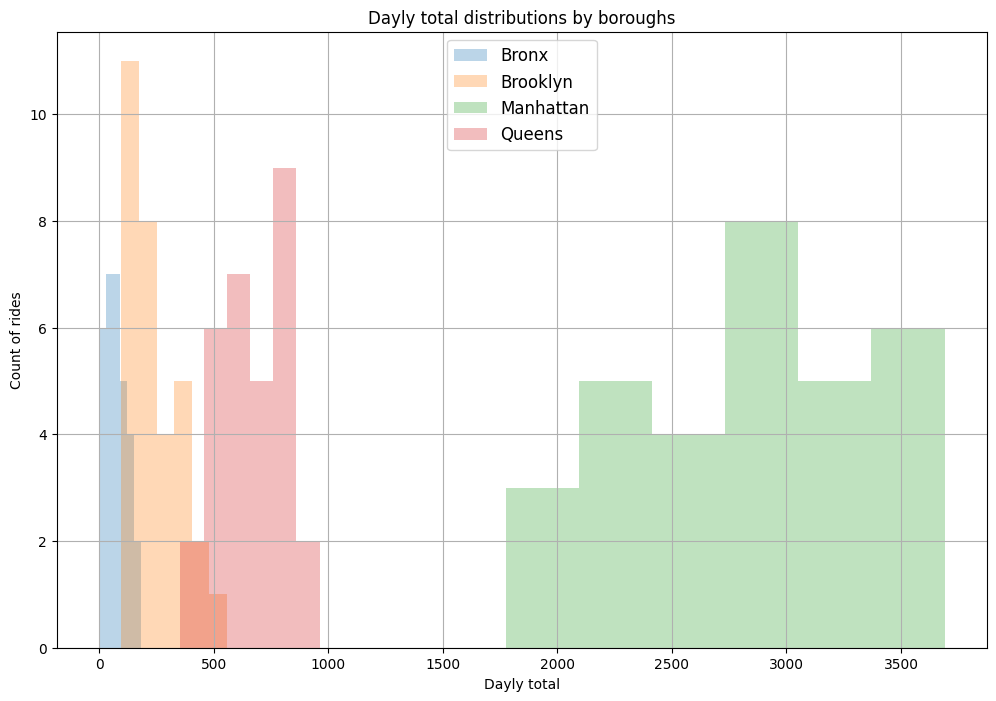

In [48]:
import matplotlib.pyplot as plt

bins = 6

plt.figure(figsize=(12, 8))

borough_pivot['Bronx'].plot(kind='hist', bins=bins, alpha=0.3, label='Bronx')
borough_pivot['Brooklyn'].plot(kind='hist', bins=bins, alpha=0.3, label='Brooklyn')
borough_pivot['Manhattan'].plot(kind='hist', bins=bins, alpha=0.3, label='Manhattan')
borough_pivot['Queens'].plot(kind='hist', bins=bins, alpha=0.3, label='Queens')

plt.title('Dayly total distributions by boroughs')
plt.xlabel('Dayly total')
plt.ylabel('Count of rides')

plt.legend(loc='upper center', fontsize='large', bbox_to_anchor=(0.5, 1), ncol=1)

plt.grid(True)
plt.show()


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1J5PCLfVovNqeGxeeBGFUSS1Kqh6-UnwR)

А ось приклад, як можна було сформувати щось подібне з допомогою функціоналу seaborn. Як на мене візуалізація за замовчанням не є зручною для розуміння.  

`Опціональне завдання`: Пограйтесь з налаштуваннями і пошукайте варіант, за якого візуалізація розподілу суми денних платежів через seaborn є на ваш погляд зручною для аналізу.

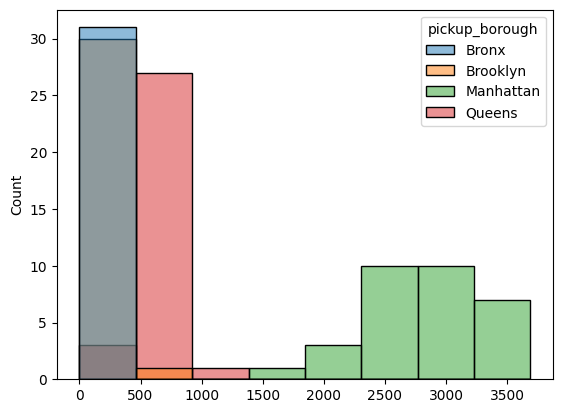

In [49]:
sns.histplot(data=borough_pivot, bins=8);

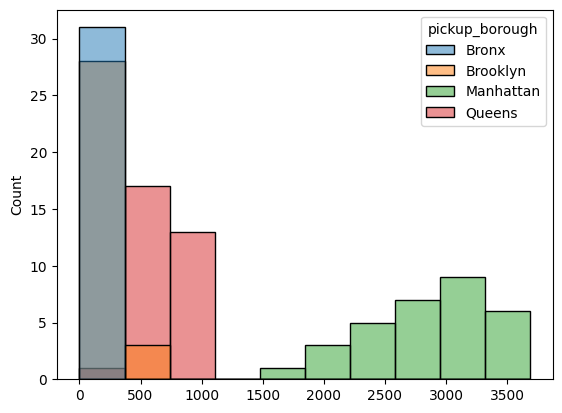

In [50]:
sns.histplot(data=borough_pivot, bins=10);

10.З допомогою seaborn виведіть гістограми суми щомісячних платежів по кольорам автомобілів (колонка `color`). На одній фігурі має бути кількість гістограм рівна кількості різних кольорів автомобілів в наборі даних. Встановіть розмір фігури (10,5) та знайдіть значення dots-per-inch для фігури за якого якість зображення буде хорошою (зображення не буде розмитим).
`Підказки:`
1. побудувати візуалізацію можна в один рядок коду, і ще один рядок - для встановлення розмірів і роздільної здатності фігури.
2. для зміни порядку відображення гістограм кольорів автомобілів (аби менша гістограма була перед, а не за більшою) можна посортувати датафрейм за полем кольору так, аби отримати той порядок, який вам потрібен.

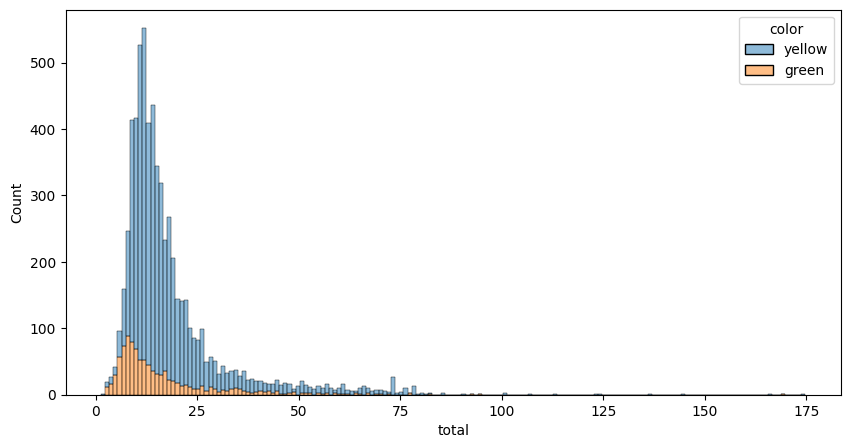

In [51]:
import seaborn as sns

df_taxi = sns.load_dataset('taxis')

plt.figure(figsize=(10, 5))

plt.rcParams['figure.dpi'] = 100

sns.histplot(data=df_taxi, x='total', hue='color', alpha=0.5, multiple='stack')

plt.show()


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=17j9hUAo0-65yEuCMHOHUlEW0nRqePOrW)

11.Цікаво, а чи є залежність між дальністю поїздки і розміром чайових? Побудуйте діаграму розсіювання між дальністю поїздки і розміром чайових. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

В очікуваному результаті я надаю графік, який би будувала я. На наведеному прикладі найскладніша частина - це зробити червоною цю лінію тренду (вона побудована з допомогою спеціального типу графіку в seaborn). Аби вказати колір лінії в тому типу графіку треба зазначити в параметрі `line_kws`, що ми хочемо лінію червоного кольору. Але якщо у вас не буде виходити лінія червоного кольору - нехай буде синього - це не критично :)

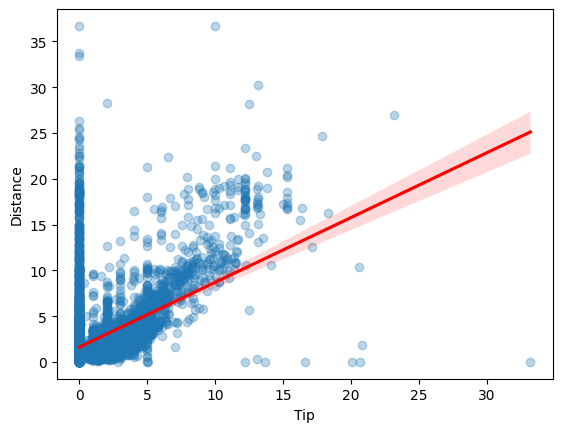

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

df_taxi = sns.load_dataset('taxis')

sns.regplot(data=df_taxi, y='distance', x='tip', scatter_kws={'alpha':0.3}, line_kws={"color": "red"})

plt.xlabel('Tip')
plt.ylabel('Distance')

plt.show()


Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=19PtgLlPTJ1iR_AxcnBDZUw-U3Ulr6Cpy)

12.Дайте відповідь на питання: що означає пряма лінія з точок, паралельна осі, за якою розташована дальність поїздки?



> Пряма лінія з точок вказує на наявність або відсутність залежності між двома змінними, які представлені на графіку.
Пряма лінія тренду допомагає візуально визначити наявність та напрямок залежності між цими двома змінними. Якщо лінія тренду має позитивний нахил (напрямлений вгору), це означає, що зі збільшенням значення однієї змінної (наприклад, розмір чайових), значення іншої змінної (дальність поїздки) також збільшується. Якщо лінія тренду має від'ємний нахил (напрямлений вниз), це означає, що зі збільшенням значення однієї змінної, значення іншої змінної зменшується.



13.Побудуйте поденну динаміку чайових по районам, в яких забрали пасажира. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати. Важливо, щоб на одному графіку було 4 лінії (всі райони, крім `NA`), які відображають динаміку чайових, була легенда і були підписи вісей. В очікуваному результаті я надаю графік, який би будувала я.

Дайте відповіді на питання:
- при початку поїздки в якому районі **найнижчий середній розмір** чайових?
- а в поїздках з якого району **найвищий середній розмір** чайових?
- при проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)?

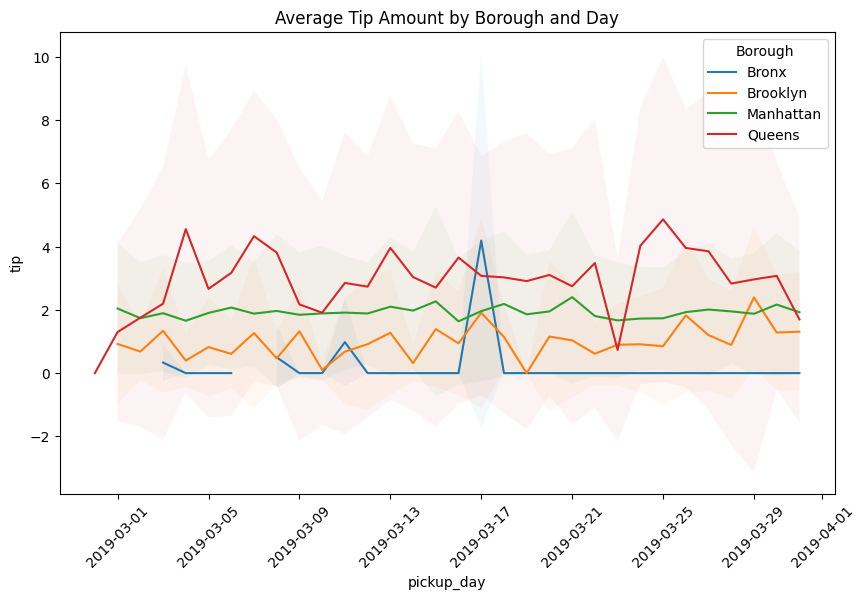

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_taxi = sns.load_dataset('taxis')

df_taxi_filtered = df_taxi[df_taxi['pickup_borough'] != 'NA']

df_grouped = df_taxi_filtered.groupby(['pickup_borough', df_taxi_filtered['pickup'].dt.date])['tip'].mean().unstack(level=0)

std_dev = df_taxi_filtered.groupby(['pickup_borough', df_taxi_filtered['pickup'].dt.date])['tip'].std().unstack(level=0)

plt.figure(figsize=(10, 6))
for column in df_grouped.columns:
    plt.plot(df_grouped.index, df_grouped[column], label=column)
    plt.fill_between(df_grouped.index, df_grouped[column] - std_dev[column], df_grouped[column] + std_dev[column], alpha=0.05)

plt.title('Average Tip Amount by Borough and Day')
plt.xlabel('pickup_day')
plt.ylabel('tip')
plt.xticks(rotation=45)
plt.legend(title='Borough')

plt.show()


1. При початку поїздки в якому районі найнижчий середній розмір чайових? **Bronx**

2. В поїздках з якого району найвищий середній розмір чайових? **Queens**

3. При проїздках з його району розмір чайових найстабільніший (найменше змінюється з дня у день)? **Manhattan**

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1yoEqYwNwyQmTTrkk_Mz6D-ruAvE-Sx8q)

14.Побудуйте box-plot розміру чайових по району (всі райони, крім `NA`) старту поїздки. Можна побудувати графік будь-яким методом, який вам до вподоби, чи хочеться потренувати.

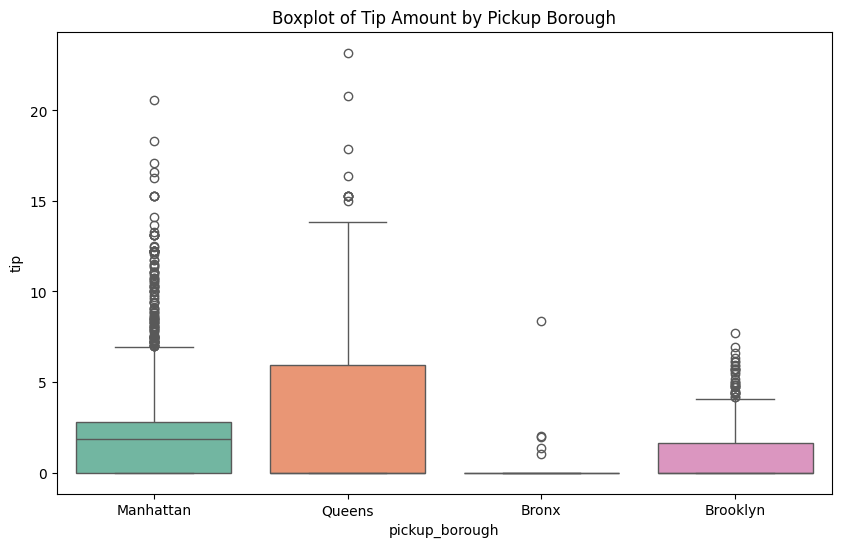

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

df_taxi = sns.load_dataset('taxis')

df_taxi_filtered = df_taxi[df_taxi['pickup_borough'] != 'NA']

plt.figure(figsize=(10, 6))
sns.boxplot(x='pickup_borough', y='tip', data=df_taxi_filtered, hue='pickup_borough', palette='Set2', legend=False)

plt.title('Boxplot of Tip Amount by Pickup Borough')
plt.xlabel('pickup_borough')
plt.ylabel('tip')

plt.show()

Один з можливих результатів (побудовано з seaborn):

![](https://drive.google.com/uc?export=view&id=1o6dFRTSj0gLQ_DMWeb7upqvuPNsL0MQc)

15.Творче завдання. Створіть ТРИ інформативних візуалізації, які б допомогли в аналізі цих даних.   

Що вам було б цікаво дізнатись про ці поїздки? Як це можна було б використати при прийнятті рішень бізнесом?
Наприклад, якщо найбільше поїздок в певний час доби, значить, треба стимулювати водіїв працювати в ці години. Якщо найбільше поїздок з певного району - треба тримати там запас авто, які б могли взяти пасажирів і т.д.
Не обмежуйте свою фантазію.

Візуалізації мають бути не тими, на які ми вже побудували вище. Але можна створювати аналогічні, просто з використанням інших полів даних. І описати, що ви бачите з тих візуалізацій.
Без виконання цього завдання ДЗ не приймаєтья. Якщо є питання щодо виконання - пишіть у чат.

15.1

Heatmap залежності середньої суми поїздок від дня тижня та години доби: Ця візуалізація дозволить виявити часи дня та дні тижня, коли попит на таксі найвищий. Наприклад, якщо на heatmap видно, що пік попиту припадає на вечірні години середи та п'ятниці, це може бути важливою інформацією для планування роботи водіїв та розподілу автомобілів.

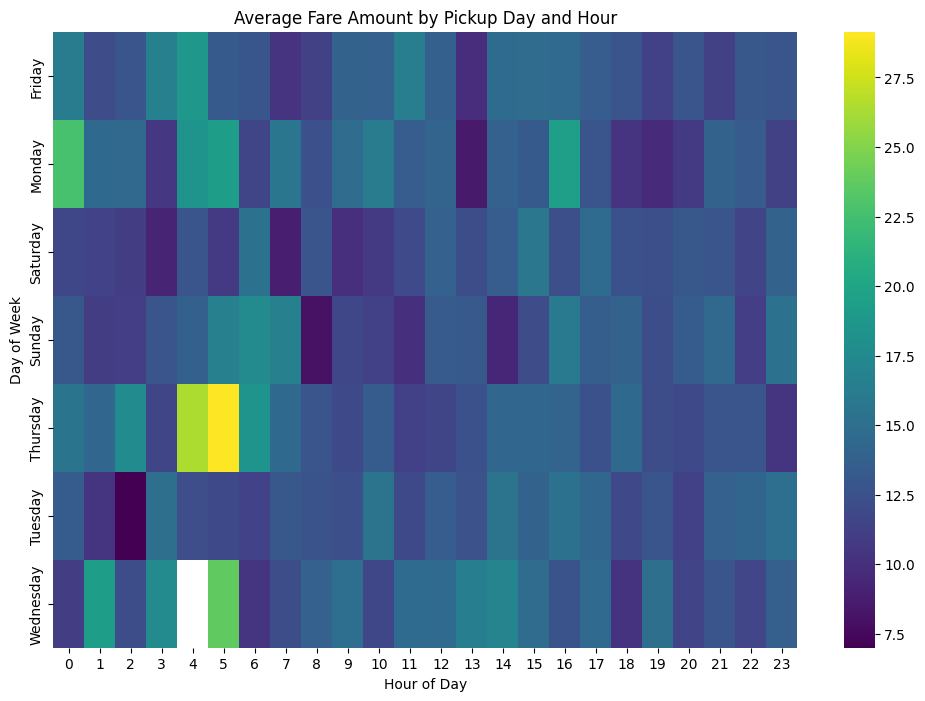

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

df_taxi = sns.load_dataset('taxis')

df_taxi['pickup_day'] = df_taxi['pickup'].dt.day_name()
df_taxi['pickup_hour'] = df_taxi['pickup'].dt.hour

plt.figure(figsize=(12, 8))
heatmap_data = df_taxi.pivot_table(index='pickup_day', columns='pickup_hour', values='fare', aggfunc='mean')
sns.heatmap(heatmap_data, cmap='viridis')

plt.title('Average Fare Amount by Pickup Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()


Найбільші середні суми поїздок спостерігаються у ранні години доби. Це може бути пов'язано з різними факторами, такими як нічні тарифи, менший трафік або більш дорогі поїздки. Протягом дня, сума поїздок залишається відносно стабільною з незначними змінами. Вечірні години (18-20) мають трохи вищу середню суму поїздок.
В понеділок та середу середні суми поїздок зазвичай нижчі у порівнянні з іншими днями. Четвер і субота мають відносно високі середні суми поїздок, особливо вранці.

Враховуючи високі середні суми поїздок у ранні години, можна розглянути можливість коригування тарифів у цей час для збільшення доходів. Можна запровадити додаткові стимули для водіїв працювати у високозавантажені години (ранні та вечірні години) для забезпечення більшої кількості автомобілів на дорозі. Маркетингові кампанії можуть бути націлені на певні дні тижня, коли середні суми поїздок є вищими, щоб залучити більше клієнтів.


15.2

Графік розподілу дистанції поїздок за різними районами: Ця візуалізація дозволить порівняти розподіл дистанцій поїздок для різних районів. Це може допомогти визначити, які райони потребують більшої кількості автомобілів для покриття більших відстаней або де можна зосередитися на коротших поїздках.

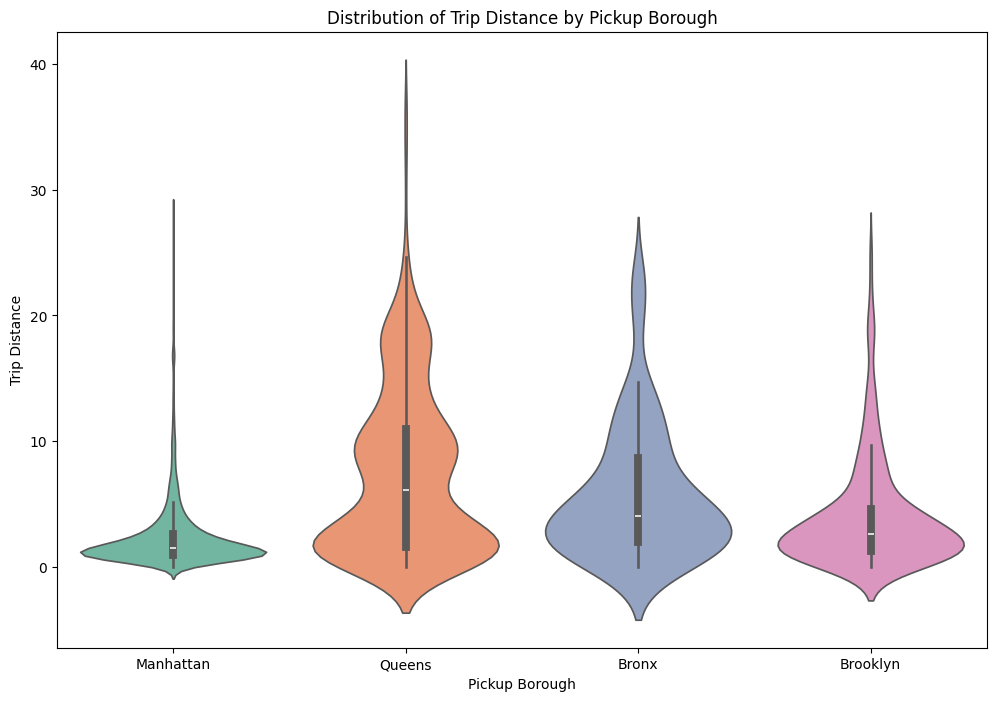

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

df_taxi = sns.load_dataset('taxis')

df_taxi_filtered = df_taxi[df_taxi['pickup_borough'] != 'NA']

plt.figure(figsize=(12, 8))
#sns.violinplot(x='pickup_borough', y='distance', data=df_taxi_filtered, palette='Set2')
sns.violinplot(x='pickup_borough', y='distance', data=df_taxi_filtered, hue='pickup_borough', palette='Set2', legend=False)


plt.title('Distribution of Trip Distance by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Trip Distance')

plt.show()

- **Manhattan**: найкоротші поїздки. Це може бути пов'язано з високою щільністю населення та наявністю багатьох місць призначення в межах короткої відстані.
- **Queens і Bronx**: мають найбільший діапазон відстаней. Це може свідчити про більш різноманітні типи поїздок, включаючи поїздки як в межах району, так і міжрайонні поїздки.
- **Brooklyn**: середній діапазон відстаней, схожий на Манхеттен, але з дещо більшими відстанями.

Ця інформація може бути корисною для оптимізації розташування таксі у різних районах. Наприклад, у Манхеттені можна очікувати більше коротких поїздок, тоді як у Квінсі та Бронксі варто підготуватись до довших поїздок.

15.3

Стовпчаста діаграма залежності середньої суми поїздок від методу оплати: Ця візуалізація дозволить зрозуміти, які методи оплати найбільш популярні серед пасажирів і як вони розподіляються в різних годинах чи районах. Наприклад, якщо один метод оплати популярний в середньому вночі, а інший - вдень, це може вказувати на різні потреби аудиторії в різний час.

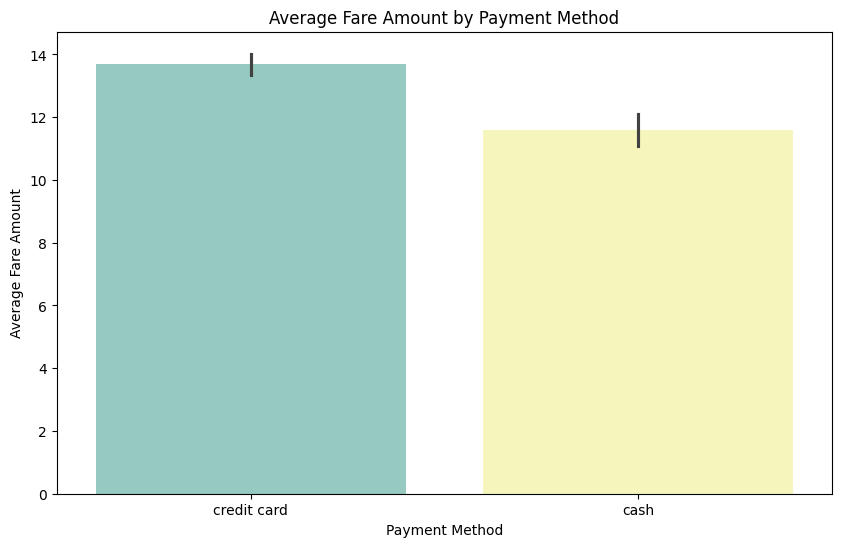

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

df_taxi = sns.load_dataset('taxis')

plt.figure(figsize=(10, 6))
sns.barplot(x='payment', y='fare', hue='payment', data=df_taxi, palette='Set3', legend=False)

plt.title('Average Fare Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Fare Amount')

plt.show()


Середній тариф для поїздок, оплачених кредитною карткою, вищий, ніж для поїздок, оплачених готівкою.

Ця різниця може свідчити про те, що пасажири, які використовують кредитні картки, можливо, роблять довші або більш дорогі поїздки.
Або ж, у випадках оплати кредитною карткою, можуть додаватися додаткові збори або чайові, що збільшує загальну суму.

Оскільки середній тариф для кредитних карток вищий, можна стимулювати пасажирів використовувати цей спосіб оплати. Це може бути зроблено через програми лояльності або знижки для тих, хто оплачує кредитною карткою.
Оцінка тарифів і послуг:
Якщо кредитні картки є переважним способом оплати, можна інвестувати в покращення інфраструктури для безготівкових розрахунків, щоб зробити цей процес більш зручним та швидким для пасажирів.